# ML Customer Analysis - Starter Notebook

This notebook provides a starting point for analyzing customer purchase patterns.

**Goal**: Identify customer segments and purchasing behaviors

**Dataset**: Customer transaction data from Q1 2026

## Setup and Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All packages imported successfully!")

✓ All packages imported successfully!


## 1. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('../data/sample_data.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (94, 6)

Columns: ['customer_id', 'purchase_date', 'product_category', 'purchase_amount', 'customer_age', 'customer_location']


,customer_id,purchase_date,product_category,purchase_amount,customer_age,customer_location
0,C001,2024-01-15,Electronics,299.99,34,Seattle
1,C002,2024-01-16,Clothing,79.99,28,Portland
2,C003,2024-01-16,Home & Garden,159.50,45,San Francisco
3,C001,2024-01-18,Books,24.99,34,Seattle
4,C004,2024-01-19,Electronics,599.99,52,Los Angeles


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        94 non-null     str    
 1   purchase_date      94 non-null     str    
 2   product_category   94 non-null     str    
 3   purchase_amount    94 non-null     float64
 4   customer_age       94 non-null     int64  
 5   customer_location  94 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 4.5 KB


In [4]:
# Summary statistics
df.describe()

,purchase_amount,customer_age
count,94.000000,94.000000
mean,220.303936,37.436170
std,203.229299,8.177544
min,19.990000,24.000000
25%,99.990000,31.000000
50%,159.745000,37.000000
75%,229.990000,44.000000
max,899.990000,52.000000


## 2. Data Cleaning and Preparation

In [5]:
# Convert purchase_date to datetime
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
customer_id          0
purchase_date        0
product_category     0
purchase_amount      0
customer_age         0
customer_location    0
dtype: int64


## 3. Exploratory Data Analysis

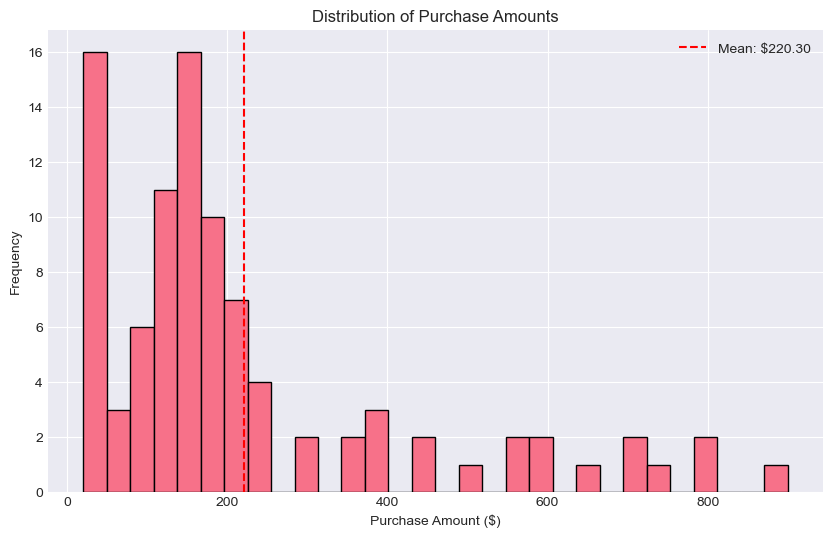

In [6]:
# Distribution of purchase amounts
plt.figure(figsize=(10, 6))
plt.hist(df['purchase_amount'], bins=30, edgecolor='black')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Purchase Amounts')
plt.axvline(df['purchase_amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["purchase_amount"].mean():.2f}')
plt.legend()
plt.show()

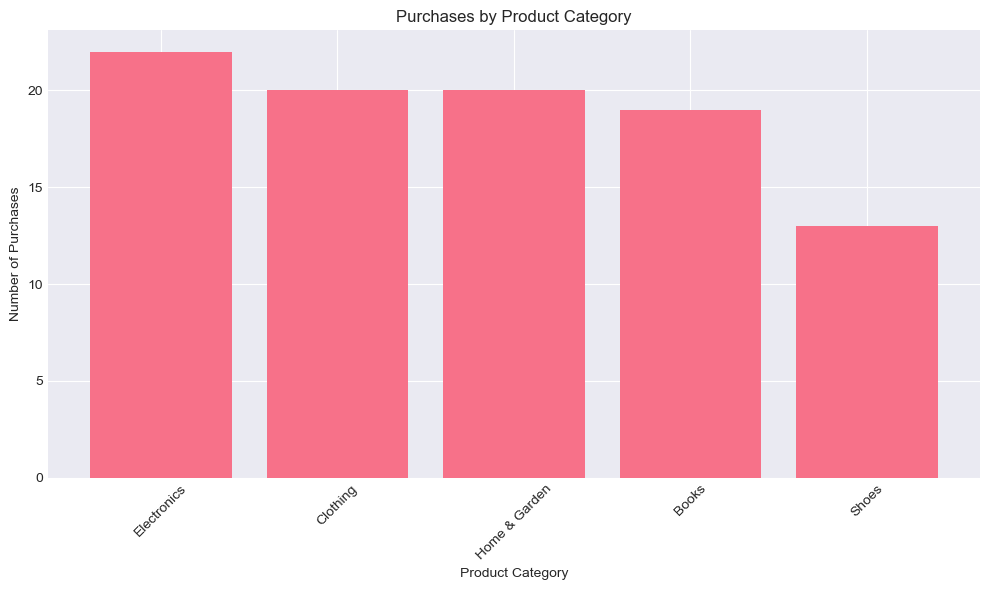

In [7]:
# Product category popularity
plt.figure(figsize=(10, 6))
category_counts = df['product_category'].value_counts()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Product Category')
plt.ylabel('Number of Purchases')
plt.title('Purchases by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

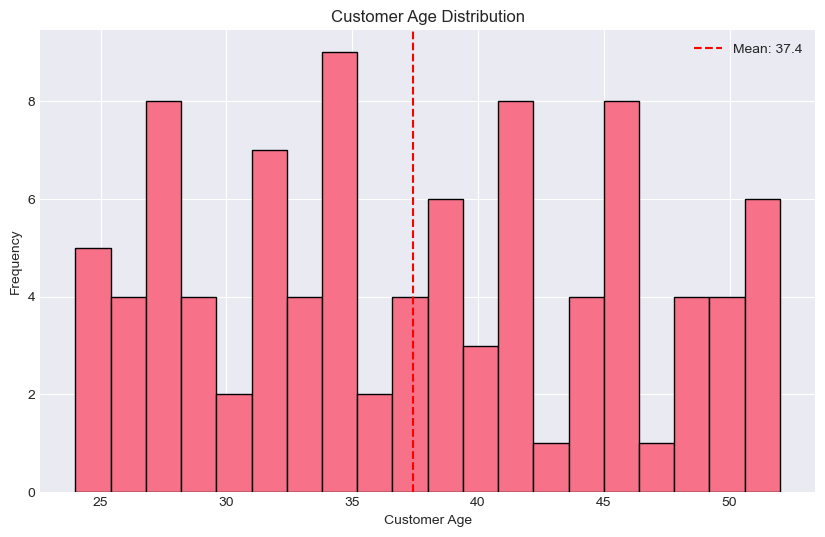

In [8]:
# Customer age distribution
plt.figure(figsize=(10, 6))
plt.hist(df['customer_age'], bins=20, edgecolor='black')
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.title('Customer Age Distribution')
plt.axvline(df['customer_age'].mean(), color='red', linestyle='--', label=f'Mean: {df["customer_age"].mean():.1f}')
plt.legend()
plt.show()

## 4. Customer Behavior Analysis

In [9]:
# Aggregate data by customer
customer_summary = df.groupby('customer_id').agg({
    'purchase_amount': ['sum', 'mean', 'count'],
    'customer_age': 'first',
    'customer_location': 'first'
})

# Flatten column names
customer_summary.columns = ['total_spend', 'avg_purchase', 'num_purchases', 'age', 'location']
customer_summary = customer_summary.reset_index()

print(f"Total unique customers: {len(customer_summary)}")
customer_summary.head(10)

Total unique customers: 50


,customer_id,total_spend,avg_purchase,num_purchases,age,location
0,C001,2024.96,506.240000,4,34,Seattle
1,C002,199.97,66.656667,3,28,Portland
2,C003,454.47,113.617500,4,45,San Francisco
3,C004,1449.97,483.323333,3,52,Los Angeles
4,C005,549.97,183.323333,3,31,Seattle
5,C006,1219.97,406.656667,3,41,San Diego
6,C007,484.97,161.656667,3,29,Denver
7,C008,669.97,223.323333,3,37,Austin
8,C009,349.98,174.990000,2,48,Boston
9,C010,154.97,51.656667,3,25,Chicago


In [10]:
# Identify high-value customers (top 20% by total spend)
spend_threshold = customer_summary['total_spend'].quantile(0.80)
high_value_customers = customer_summary[customer_summary['total_spend'] >= spend_threshold]

print(f"High-value customer threshold: ${spend_threshold:.2f}")
print(f"Number of high-value customers: {len(high_value_customers)}")
print(f"\nHigh-value customers:")
high_value_customers.sort_values('total_spend', ascending=False)

High-value customer threshold: $673.97
Number of high-value customers: 10

High-value customers:


,customer_id,total_spend,avg_purchase,num_purchases,age,location
0,C001,2024.96,506.240000,4,34,Seattle
3,C004,1449.97,483.323333,3,52,Los Angeles
5,C006,1219.97,406.656667,3,41,San Diego
11,C012,1069.97,356.656667,3,44,Phoenix
14,C015,969.97,323.323333,3,39,Philadelphia
43,C044,799.99,799.990000,1,42,Arlington
29,C030,749.99,749.990000,1,47,Tucson
19,C020,729.98,364.990000,2,46,San Antonio
48,C049,699.99,699.990000,1,52,Bakersfield
10,C011,689.97,229.990000,3,33,Miami


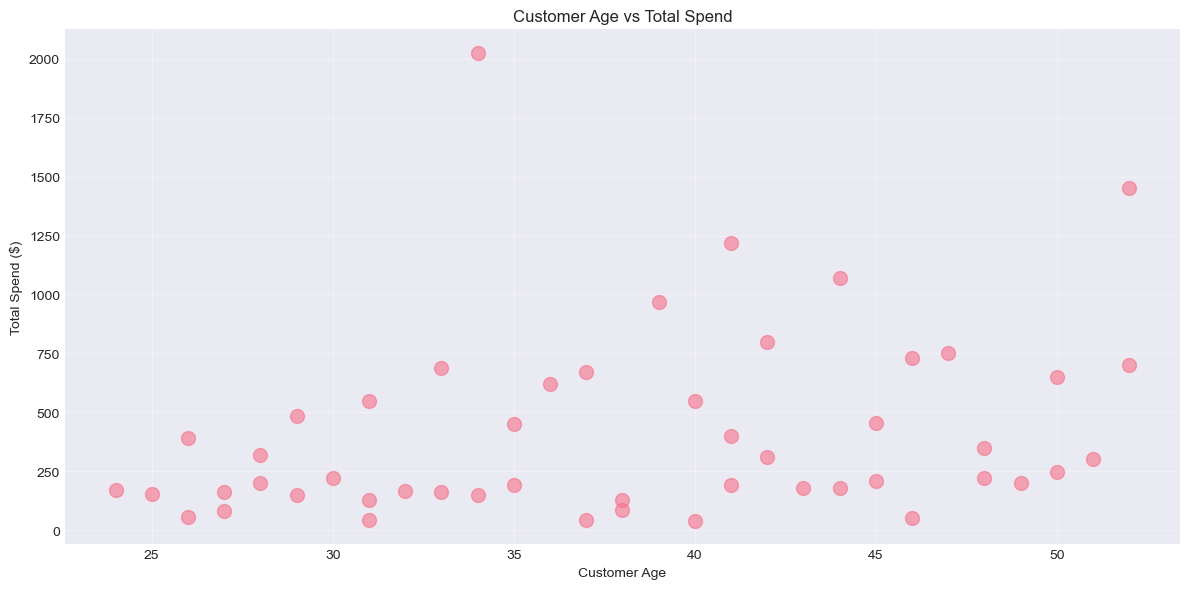

In [11]:
# Scatter plot: Age vs Total Spend
plt.figure(figsize=(12, 6))
plt.scatter(customer_summary['age'], customer_summary['total_spend'], alpha=0.6, s=100)
plt.xlabel('Customer Age')
plt.ylabel('Total Spend ($)')
plt.title('Customer Age vs Total Spend')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Customer Segmentation with K-Means Clustering

In [12]:
# Prepare features for clustering
features = customer_summary[['total_spend', 'avg_purchase', 'num_purchases', 'age']].copy()

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Features prepared for clustering:")
print(f"Shape: {features_scaled.shape}")

Features prepared for clustering:
Shape: (50, 4)


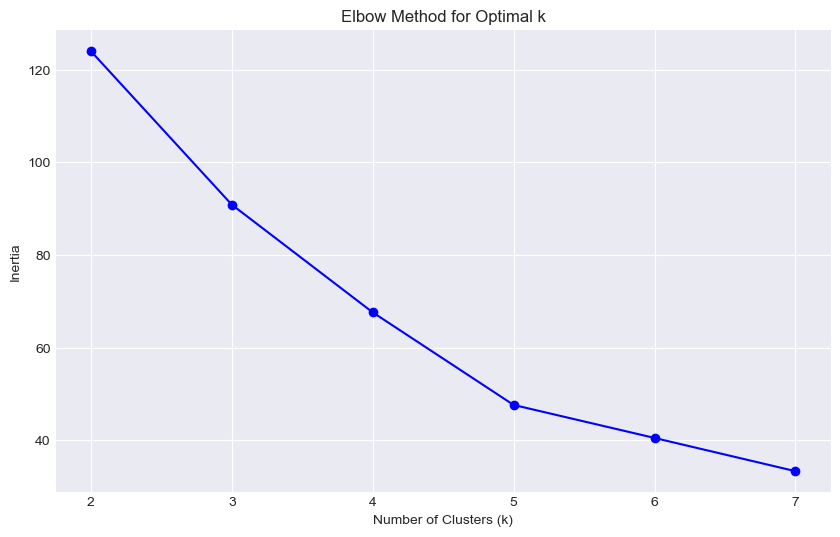

In [13]:
# Determine optimal number of clusters using elbow method
inertias = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [14]:
# Apply K-Means with optimal k (typically 3-4 based on elbow curve)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_summary['cluster'] = kmeans.fit_predict(features_scaled)

print(f"Clustering complete with k={optimal_k}")
print(f"\nCluster sizes:")
print(customer_summary['cluster'].value_counts().sort_index())

Clustering complete with k=3

Cluster sizes:
cluster
0    15
1    25
2    10
Name: count, dtype: int64


In [15]:
# Analyze cluster characteristics
cluster_profiles = customer_summary.groupby('cluster').agg({
    'total_spend': ['mean', 'min', 'max'],
    'avg_purchase': 'mean',
    'num_purchases': 'mean',
    'age': 'mean'
}).round(2)

print("\nCluster Profiles:")
cluster_profiles


Cluster Profiles:


total_spend                  avg_purchase num_purchases    age
               mean     min      max         mean          mean   mean
cluster                                                               
0            374.61   79.98   689.97       139.84          2.67  31.07
1            188.99   39.99   549.98       150.56          1.28  39.48
2           1036.48  649.99  2024.96       534.12          2.20  44.70

## 6. Visualize Clusters

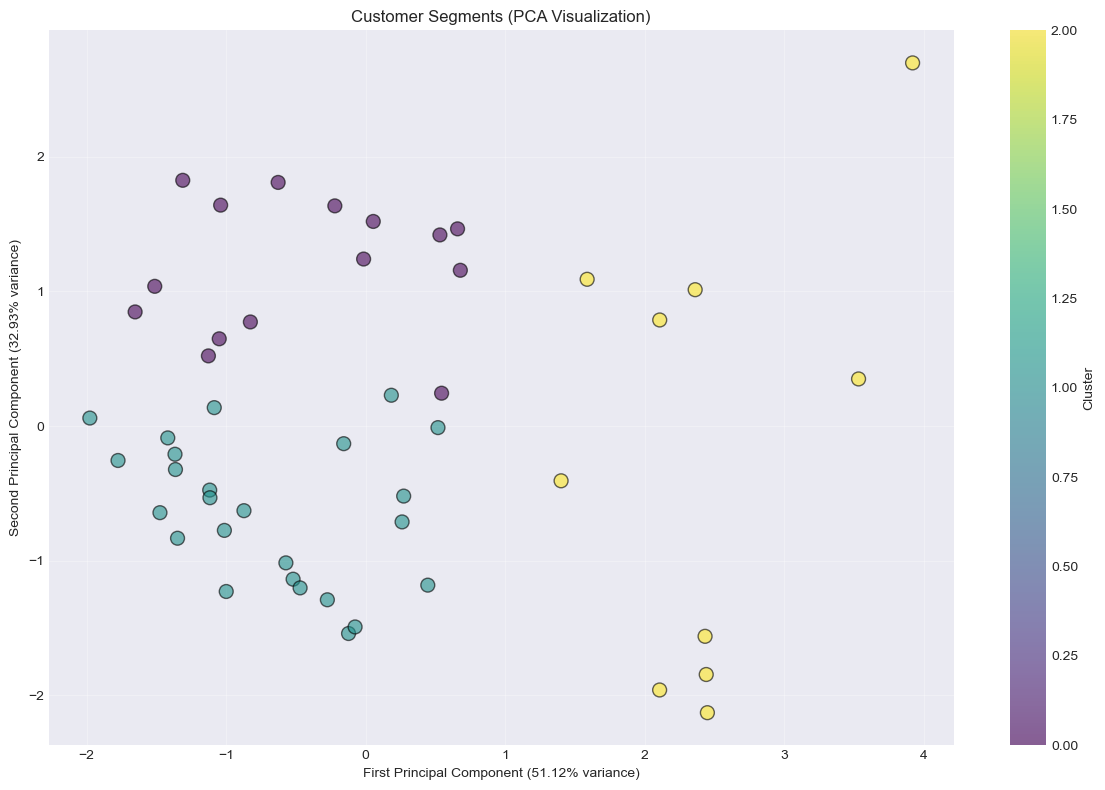

In [16]:
# Use PCA for 2D visualization
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

# Create scatter plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1], 
                      c=customer_summary['cluster'], 
                      cmap='viridis', 
                      s=100, 
                      alpha=0.6,
                      edgecolors='black')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Customer Segments (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

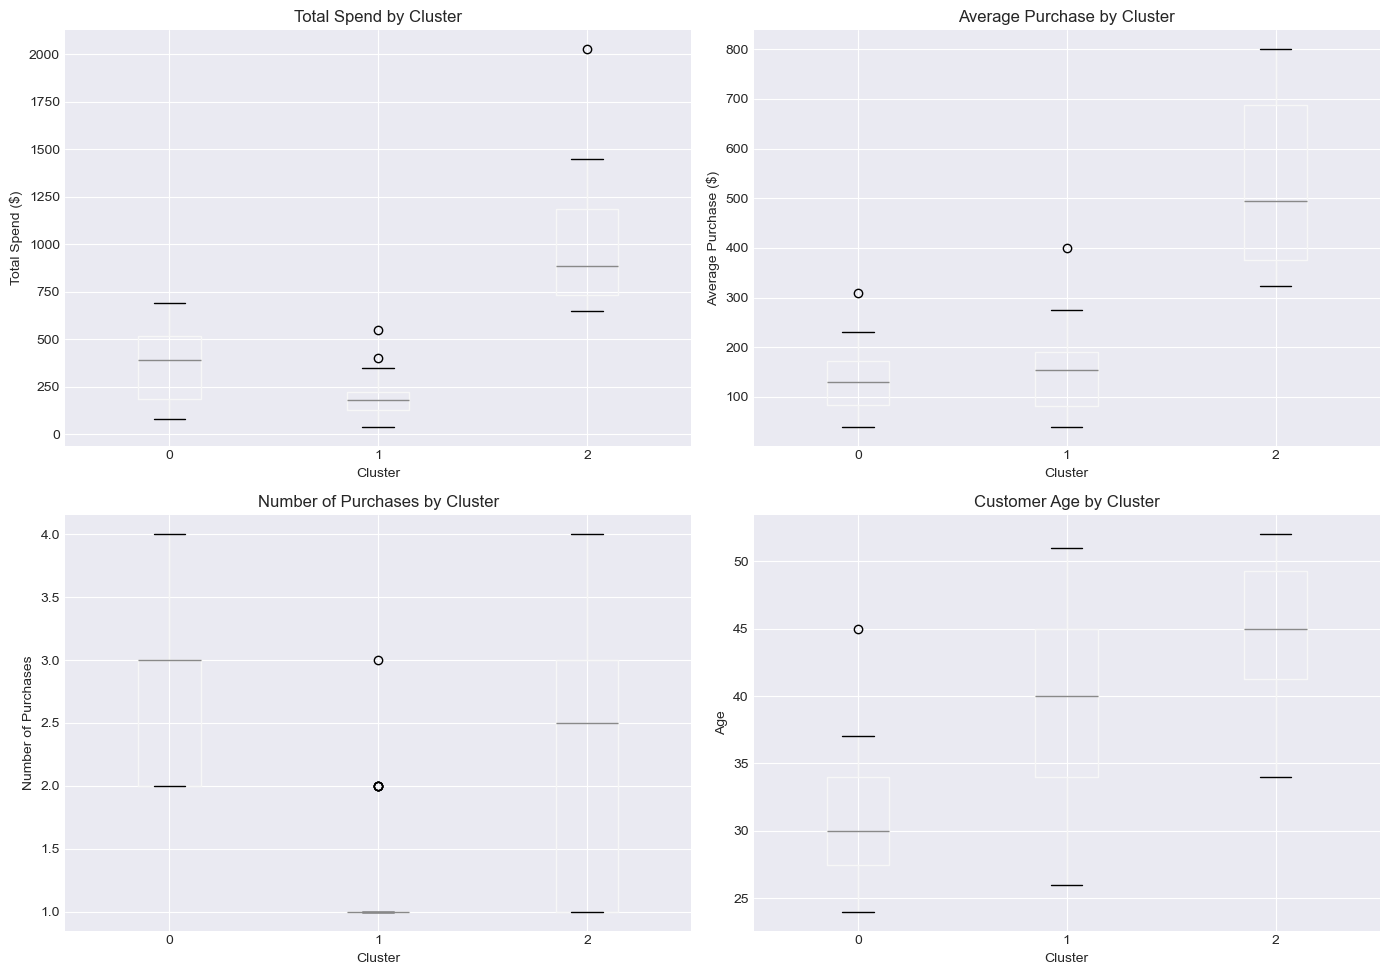

In [17]:
# Box plots for cluster comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total Spend
customer_summary.boxplot(column='total_spend', by='cluster', ax=axes[0, 0])
axes[0, 0].set_title('Total Spend by Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Total Spend ($)')

# Average Purchase
customer_summary.boxplot(column='avg_purchase', by='cluster', ax=axes[0, 1])
axes[0, 1].set_title('Average Purchase by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Purchase ($)')

# Number of Purchases
customer_summary.boxplot(column='num_purchases', by='cluster', ax=axes[1, 0])
axes[1, 0].set_title('Number of Purchases by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Number of Purchases')

# Age
customer_summary.boxplot(column='age', by='cluster', ax=axes[1, 1])
axes[1, 1].set_title('Customer Age by Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Age')

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

## 7. Insights and Recommendations

In [18]:
# Summarize findings
print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)

print(f"\n1. CUSTOMER BASE:")
print(f"   - Total customers: {len(customer_summary)}")
print(f"   - Total transactions: {len(df)}")
print(f"   - Average purchases per customer: {customer_summary['num_purchases'].mean():.2f}")

print(f"\n2. REVENUE:")
print(f"   - Total revenue: ${df['purchase_amount'].sum():.2f}")
print(f"   - Average transaction: ${df['purchase_amount'].mean():.2f}")
print(f"   - Average customer lifetime value: ${customer_summary['total_spend'].mean():.2f}")

print(f"\n3. CUSTOMER SEGMENTS:")
for cluster in range(optimal_k):
    cluster_data = customer_summary[customer_summary['cluster'] == cluster]
    print(f"   Cluster {cluster}:")
    print(f"   - Size: {len(cluster_data)} customers")
    print(f"   - Avg total spend: ${cluster_data['total_spend'].mean():.2f}")
    print(f"   - Avg purchases: {cluster_data['num_purchases'].mean():.1f}")
    print(f"   - Avg age: {cluster_data['age'].mean():.1f}")
    print()

print("=" * 60)

KEY INSIGHTS

1. CUSTOMER BASE:
   - Total customers: 50
   - Total transactions: 94
   - Average purchases per customer: 1.88

2. REVENUE:
   - Total revenue: $20708.57
   - Average transaction: $220.30
   - Average customer lifetime value: $414.17

3. CUSTOMER SEGMENTS:
   Cluster 0:
   - Size: 15 customers
   - Avg total spend: $374.61
   - Avg purchases: 2.7
   - Avg age: 31.1

   Cluster 1:
   - Size: 25 customers
   - Avg total spend: $188.99
   - Avg purchases: 1.3
   - Avg age: 39.5

   Cluster 2:
   - Size: 10 customers
   - Avg total spend: $1036.48
   - Avg purchases: 2.2
   - Avg age: 44.7



## Next Steps

### Further Analysis Ideas:
1. **Temporal Analysis**: Analyze purchase patterns over time
2. **Location Analysis**: Compare customer behavior by geographic region
3. **Category Preferences**: Identify which clusters prefer which product categories
4. **Predictive Modeling**: Build models to predict high-value customers
5. **Churn Analysis**: Identify customers at risk of not returning

### Business Recommendations:
1. Target high-value segments with personalized marketing
2. Develop retention strategies for each cluster
3. Cross-sell products based on cluster preferences
4. Optimize inventory for popular categories
5. Create age-appropriate marketing campaigns